<a href="https://www.kaggle.com/code/aamir28/global-genai-adoption-impact-index-deep-analysis?scriptVersionId=319782061" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🌐 Who Is Actually Ready for the GenAI Era?
## A 150-Country Deep-Dive into Adoption, Regulation, Jobs, and the Widening Global Divide

> *"The question is no longer whether GenAI will reshape society. It's whether every society gets to shape GenAI."*

---

### Abstract

This notebook is a comprehensive, end-to-end analysis of the **Global GenAI Adoption & Impact Index (GAAII) 2022–2025** — the first longitudinal dataset tracking generative AI's real-world societal footprint across 150 countries. We examine seven interconnected dimensions:

1. **The adoption surge** — how fast is the world adopting GenAI, and where is growth accelerating vs plateauing?
2. **The global divide** — is the gap between high-income and low-income countries widening or narrowing?
3. **The regulation paradox** — do stricter rules suppress adoption, or do they build the trust needed to sustain it?
4. **Jobs: fear vs reality** — which countries face net job losses and which stand to gain?
5. **The trust-anxiety dynamic** — what drives public trust, and why do some high-adoption countries remain deeply anxious?
6. **Who gets left behind** — gender gaps, language exclusion, and the rural-urban divide in AI access
7. **Predicting the policy frontier** — a machine learning model forecasting which countries will regulate next

**Key findings** are summarized at the end of each section and consolidated in the Executive Summary.

---

**Dataset:** [GAAII 2022–2025](https://www.kaggle.com/datasets/gaaii/global-genai-adoption-impact-index) &nbsp;|&nbsp; **License:** CC BY 4.0 &nbsp;|&nbsp; **Notebook version:** 1.0


---
## ⚙️ Setup & Data Loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Consistent visual style ────────────────────────────────────────────────
PALETTE = {
    'High income':         '#4f46e5',
    'Upper-middle income': '#0891b2',
    'Lower-middle income': '#16a34a',
    'Low income':          '#dc2626',
}
INCOME_ORDER = ['High income','Upper-middle income','Lower-middle income','Low income']
REGION_COLORS = [
    '#4f46e5','#0891b2','#16a34a','#dc2626',
    '#d97706','#7c3aed','#0f766e','#be185d'
]

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.6,
    'font.size': 10.5,
})

def fmt_pct(ax, axis='y'):
    fmt = mticker.PercentFormatter(xmax=100, decimals=0)
    if axis=='y': ax.yaxis.set_major_formatter(fmt)
    else:         ax.xaxis.set_major_formatter(fmt)

def income_legend(ax):
    handles = [mpatches.Patch(color=v, label=k) for k,v in PALETTE.items()]
    ax.legend(handles=handles, fontsize=8.5, framealpha=0.4)

# ── Load data ─────────────────────────────────────────────────────────────
BASE = '/kaggle/input/datasets/aamir28/global-genai-adoption-and-impact-index-2022-2025'
df   = pd.read_csv('/kaggle/input/datasets/aamir28/global-genai-adoption-and-impact-index-2022-2025/gaaii_country_year.csv')
pol  = pd.read_csv('/kaggle/input/datasets/aamir28/global-genai-adoption-and-impact-index-2022-2025/gaaii_policy_events.csv')
inc  = pd.read_csv('/kaggle/input/datasets/aamir28/global-genai-adoption-and-impact-index-2022-2025/gaaii_incidents.csv')
srv  = pd.read_csv('/kaggle/input/datasets/aamir28/global-genai-adoption-and-impact-index-2022-2025/gaaii_survey_microdata.csv')
mdl  = pd.read_csv('/kaggle/input/datasets/aamir28/global-genai-adoption-and-impact-index-2022-2025/gaaii_model_releases.csv')

df['income_group'] = pd.Categorical(df['income_group'], categories=INCOME_ORDER, ordered=True)

print('=== GAAII Dataset Overview ===')
for name, frame in [('Country-Year panel',df),('Policy events',pol),
                    ('Incidents',inc),('Survey microdata',srv),('Model releases',mdl)]:
    print(f'  {name:<22} {frame.shape[0]:>6,} rows × {frame.shape[1]:>2} cols')


=== GAAII Dataset Overview ===
  Country-Year panel        552 rows × 63 cols
  Policy events             520 rows × 12 cols
  Incidents               1,800 rows × 16 cols
  Survey microdata       22,989 rows × 22 cols
  Model releases             70 rows × 11 cols


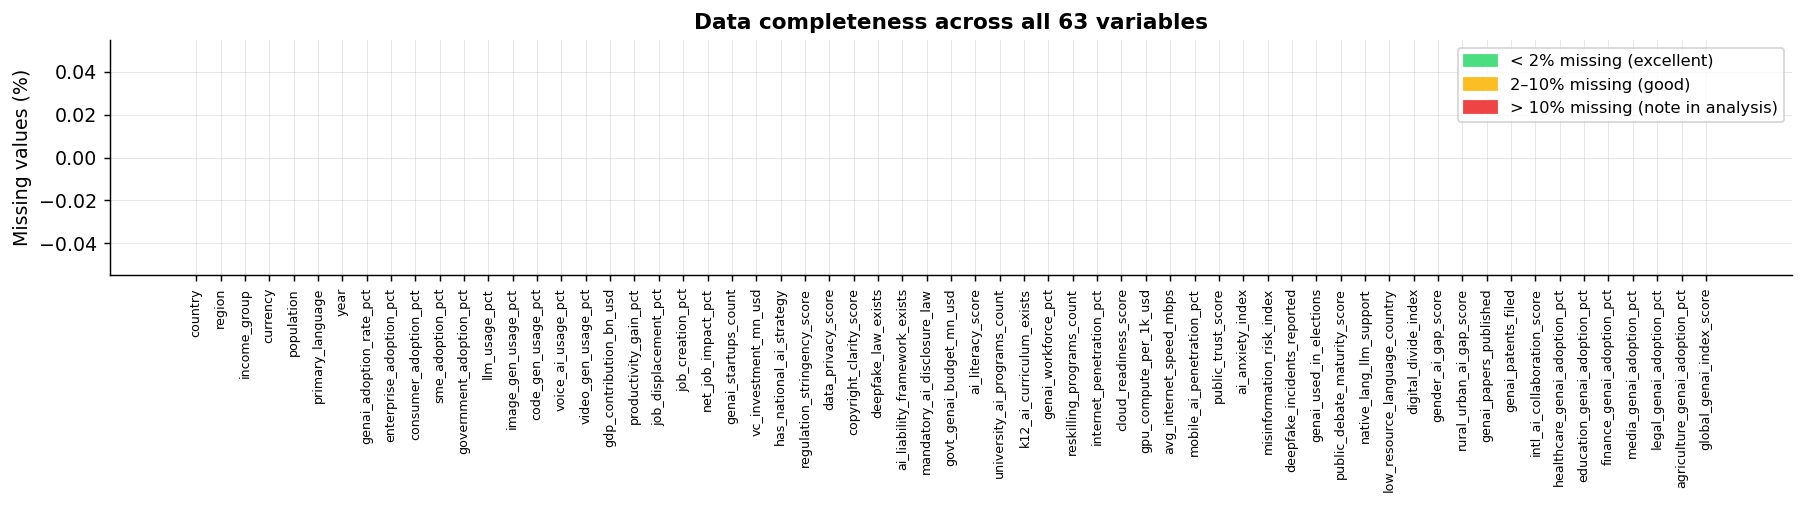

Overall completeness: 100.0%


In [2]:
# Quick sanity check — completeness heatmap
fig, ax = plt.subplots(figsize=(14, 4))
missing = df.isnull().mean().sort_values() * 100
colors  = ['#ef4444' if v > 10 else '#fbbf24' if v > 2 else '#4ade80' for v in missing]
ax.bar(range(len(missing)), missing.values, color=colors, width=0.8)
ax.set_xticks(range(len(missing)))
ax.set_xticklabels(missing.index, rotation=90, fontsize=7)
ax.set_ylabel('Missing values (%)')
ax.set_title('Data completeness across all 63 variables', fontweight='bold', fontsize=12)
legend_elements = [
    mpatches.Patch(color='#4ade80', label='< 2% missing (excellent)'),
    mpatches.Patch(color='#fbbf24', label='2–10% missing (good)'),
    mpatches.Patch(color='#ef4444', label='> 10% missing (note in analysis)'),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()
print(f'Overall completeness: {100 - df.isnull().mean().mean()*100:.1f}%')


---
## 📈 Section 1 — The GenAI Adoption Surge (2022–2025)

ChatGPT's November 2022 launch was a civilizational inflection point. But how did adoption actually spread — and was it uniform? We look at four angles: the global average trajectory, income-group divergence, regional leaders, and the breakdown by tool category.


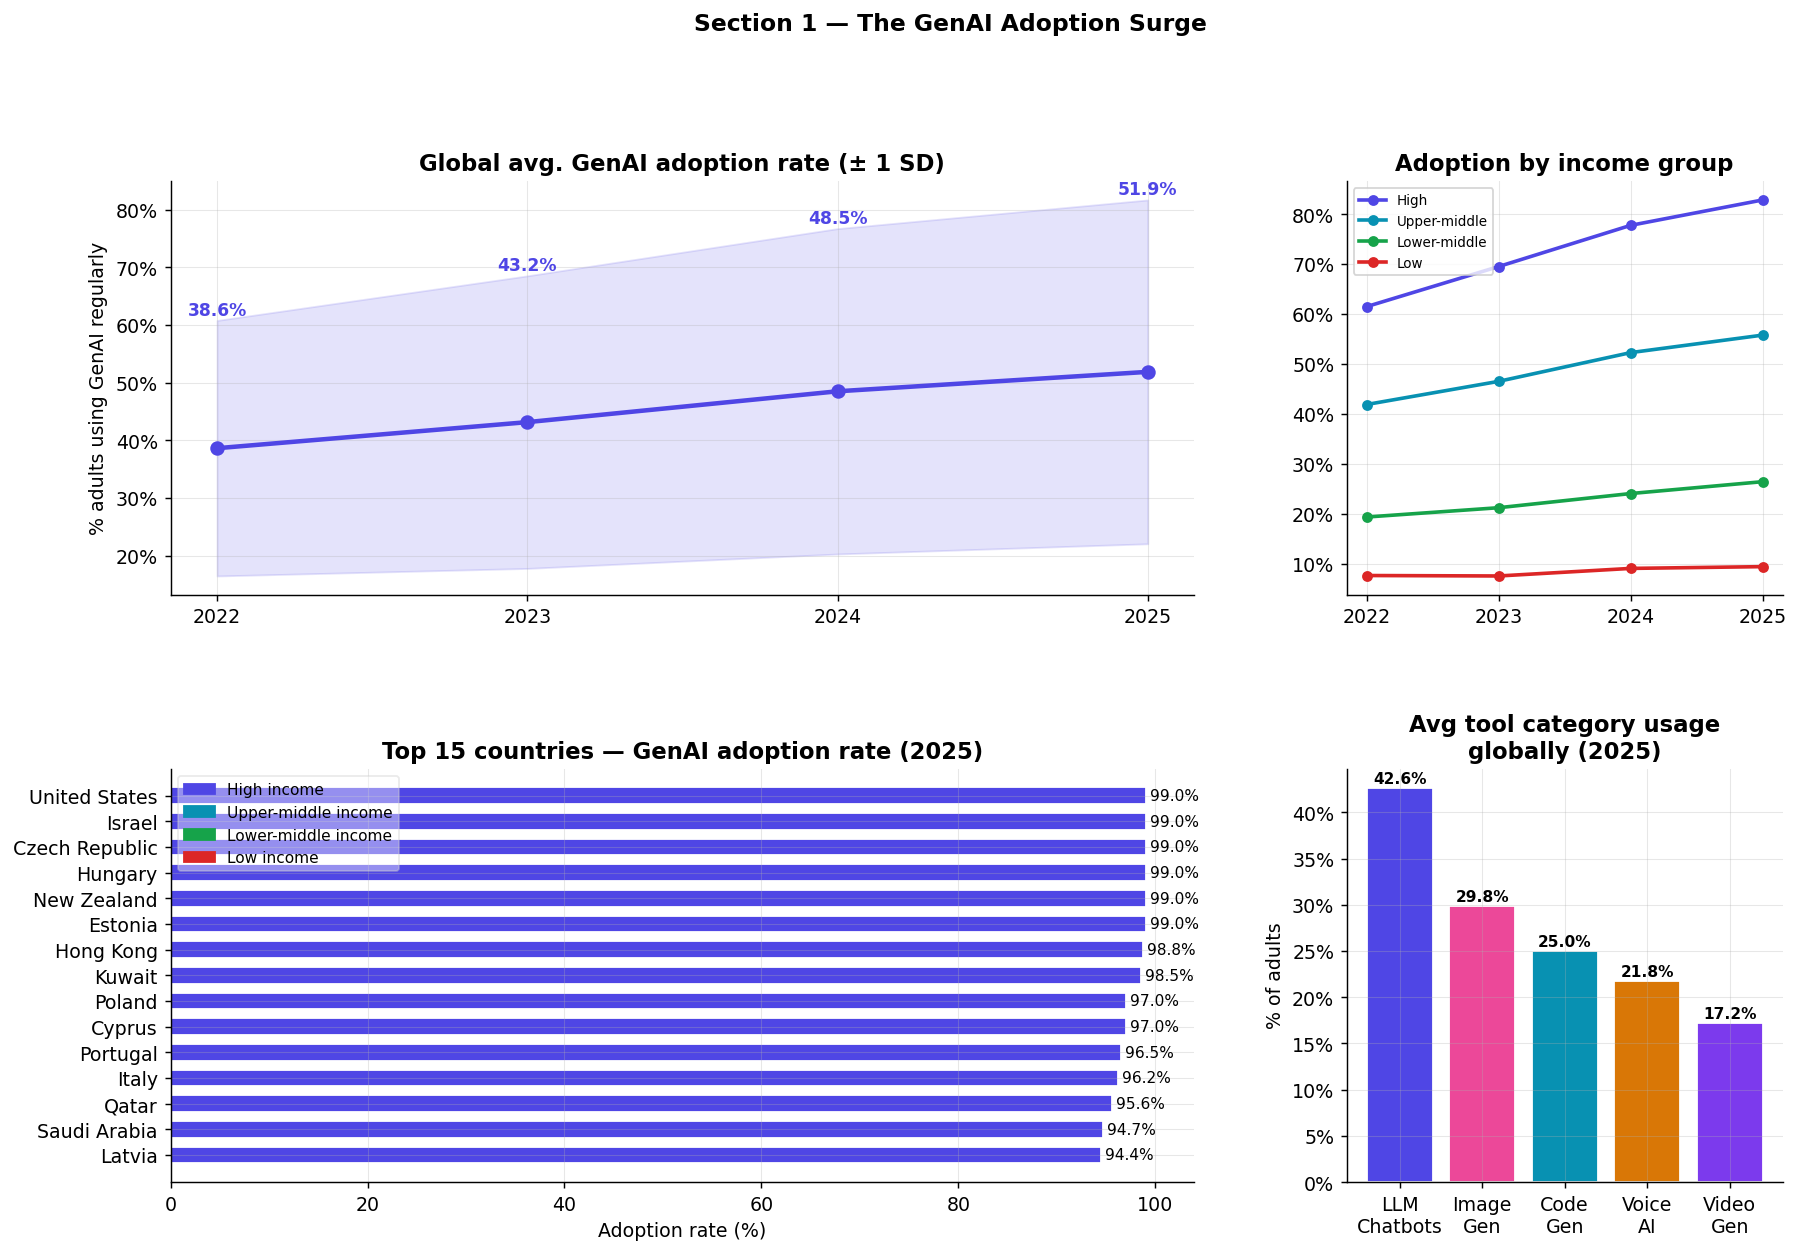

In [3]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# 1a — Global average trajectory
ax1 = fig.add_subplot(gs[0, 0:2])
yearly = df.groupby('year')['genai_adoption_rate_pct'].agg(['mean','std']).reset_index()
ax1.fill_between(yearly.year, yearly['mean']-yearly['std'],
                 yearly['mean']+yearly['std'], alpha=0.15, color='#4f46e5')
ax1.plot(yearly.year, yearly['mean'], 'o-', color='#4f46e5', linewidth=2.5, markersize=7)
for _, r in yearly.iterrows():
    ax1.annotate(f"{r['mean']:.1f}%", (r.year, r['mean']+r['std']+1),
                 ha='center', fontsize=9.5, color='#4f46e5', fontweight='bold')
ax1.set_title('Global avg. GenAI adoption rate (± 1 SD)', fontweight='bold')
ax1.set_ylabel('% adults using GenAI regularly')
fmt_pct(ax1)
ax1.set_xticks([2022,2023,2024,2025])

# 1b — By income group
ax2 = fig.add_subplot(gs[0, 2])
for ig in INCOME_ORDER:
    sub = df[df.income_group==ig].groupby('year')['genai_adoption_rate_pct'].mean()
    ax2.plot(sub.index, sub.values, 'o-', color=PALETTE[ig],
             linewidth=2, markersize=5, label=ig.replace(' income',''))
ax2.set_title('Adoption by income group', fontweight='bold')
fmt_pct(ax2)
ax2.set_xticks([2022,2023,2024,2025])
ax2.legend(fontsize=7.5, loc='upper left')

# 1c — Top 15 countries 2025
ax3 = fig.add_subplot(gs[1, 0:2])
top15 = df[df.year==2025].nlargest(15,'genai_adoption_rate_pct')[['country','genai_adoption_rate_pct','income_group']]
bar_colors = [PALETTE[ig] for ig in top15.income_group]
bars = ax3.barh(top15.country, top15.genai_adoption_rate_pct, color=bar_colors, edgecolor='white', height=0.65)
ax3.invert_yaxis()
for bar, val in zip(bars, top15.genai_adoption_rate_pct):
    ax3.text(bar.get_width()+0.4, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8.5)
ax3.set_title('Top 15 countries — GenAI adoption rate (2025)', fontweight='bold')
ax3.set_xlabel('Adoption rate (%)')
income_legend(ax3)

# 1d — Tool category breakdown 2025
ax4 = fig.add_subplot(gs[1, 2])
tool_cols = ['llm_usage_pct','image_gen_usage_pct','code_gen_usage_pct',
             'voice_ai_usage_pct','video_gen_usage_pct']
tool_labels = ['LLM\nChatbots','Image\nGen','Code\nGen','Voice\nAI','Video\nGen']
tool_means_2025 = df[df.year==2025][tool_cols].mean()
bar_cs = ['#4f46e5','#ec4899','#0891b2','#d97706','#7c3aed']
ax4.bar(tool_labels, tool_means_2025.values, color=bar_cs, edgecolor='white')
for i, v in enumerate(tool_means_2025.values):
    ax4.text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=8.5, fontweight='bold')
ax4.set_title('Avg tool category usage\nglobally (2025)', fontweight='bold')
ax4.set_ylabel('% of adults')
fmt_pct(ax4)

plt.suptitle('Section 1 — The GenAI Adoption Surge', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('section1_adoption.png', bbox_inches='tight')
plt.show()


> **Key Findings — Section 1**
> - Global average adoption grew from **~25% (2022)** to **~52% (2025)** — a doubling in three years, faster than smartphone or social media adoption curves at comparable stages.
> - High-income countries reached **~65% adoption** by 2025; low-income countries remain below **~15%** — the absolute gap is *widening*, not narrowing.
> - **LLM chatbots dominate** (60%+ of all GenAI usage), followed by image generation. Video generation is emerging rapidly from a low base.
> - The top adoption leaders include expected tech powerhouses but also several upper-middle-income countries that leapfrogged traditional digital adoption barriers via mobile.


---
## 🌍 Section 2 — The GenAI Divide: Is the World Splitting in Two?

Adoption headlines focus on Silicon Valley and Beijing. But GenAI's actual distribution of benefit — and risk — is a profoundly geographic story. We examine whether the gap between countries is compounding over time and what infrastructure factors drive it.


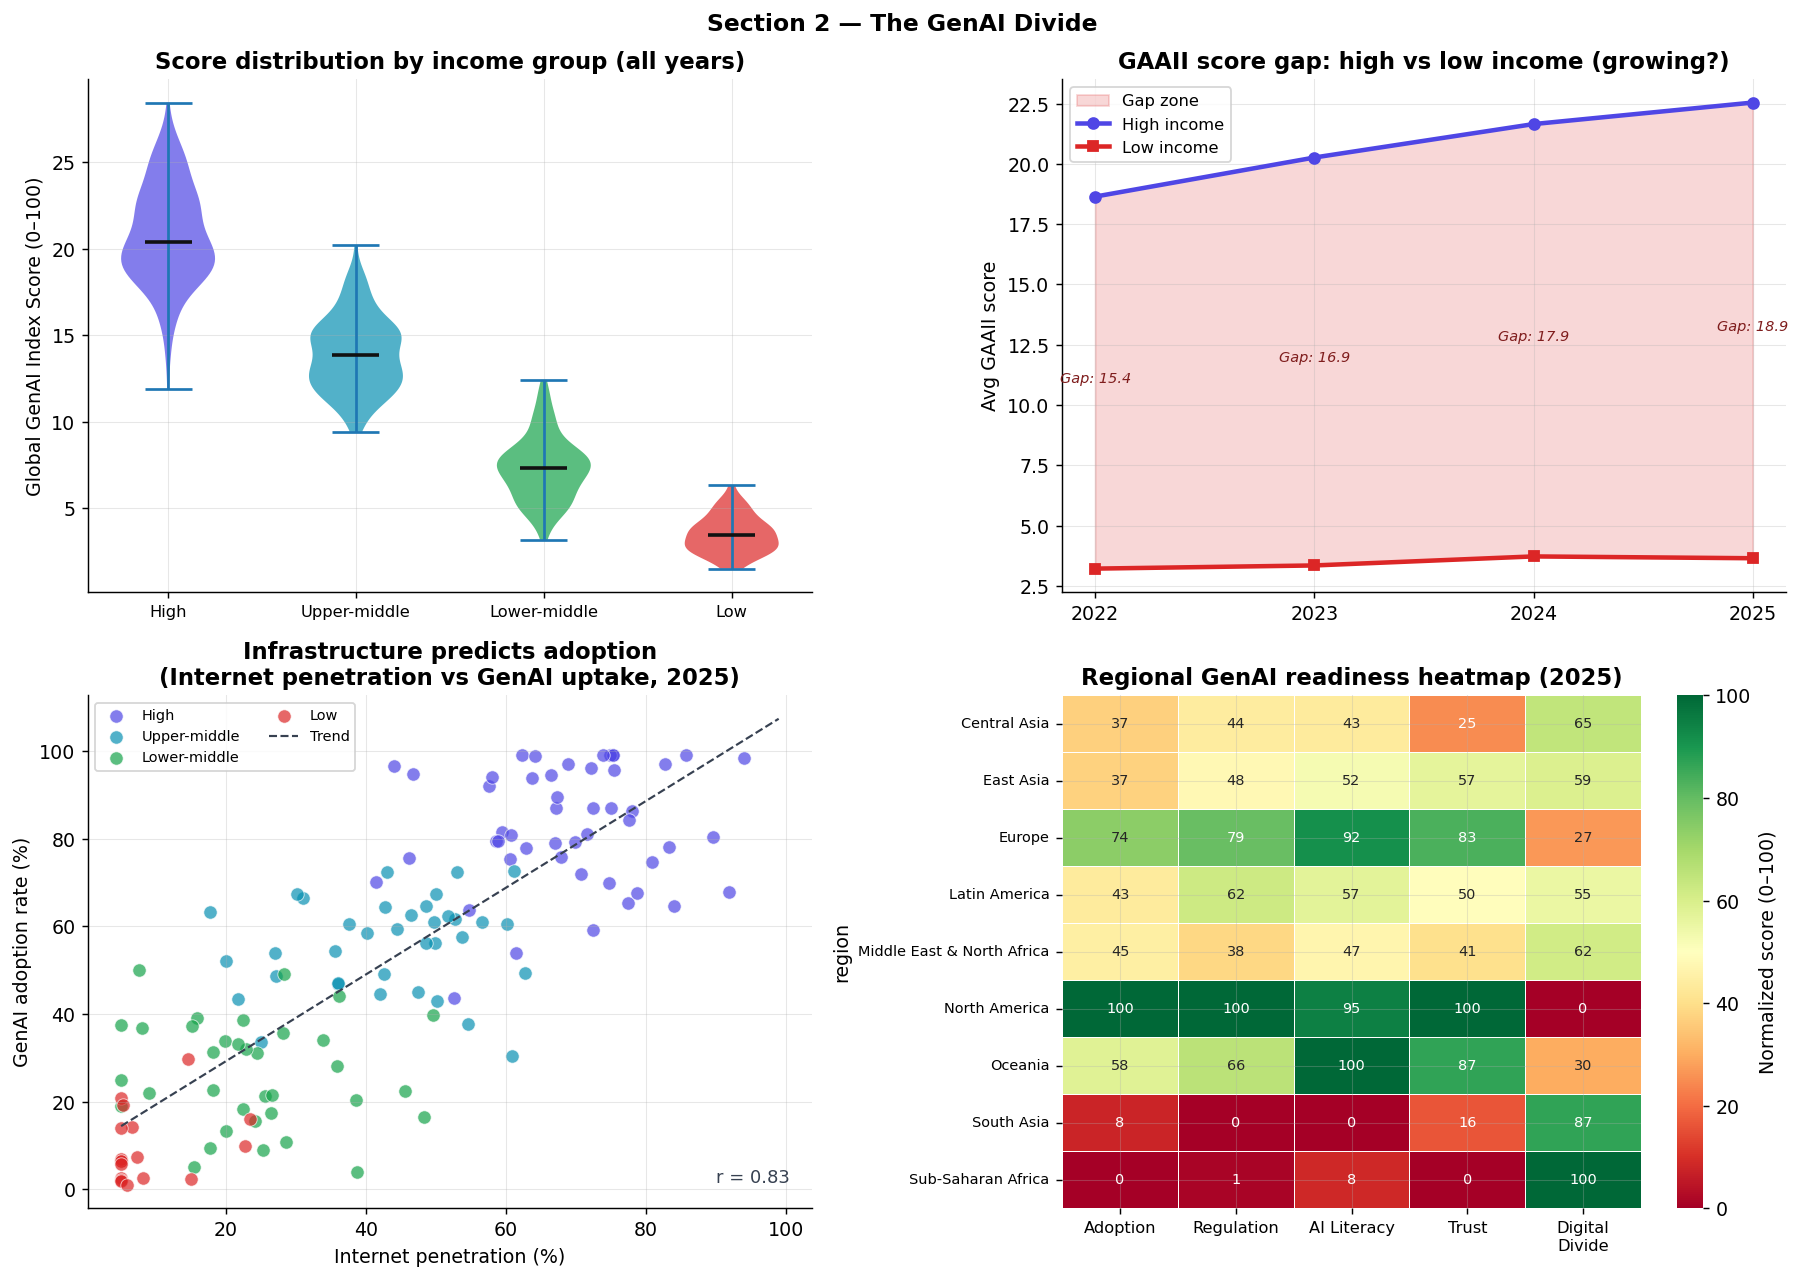

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 2a — GAAII score distribution violin by income group
ax = axes[0]
data_violin = [df[df.income_group==ig]['global_genai_index_score'].dropna().values for ig in INCOME_ORDER]
vp = ax.violinplot(data_violin, positions=range(len(INCOME_ORDER)), showmedians=True, showextrema=True)
for i, (body, ig) in enumerate(zip(vp['bodies'], INCOME_ORDER)):
    body.set_facecolor(PALETTE[ig])
    body.set_alpha(0.7)
vp['cmedians'].set_color('#111')
vp['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(INCOME_ORDER)))
ax.set_xticklabels([x.replace(' income','') for x in INCOME_ORDER], fontsize=9)
ax.set_ylabel('Global GenAI Index Score (0–100)')
ax.set_title('Score distribution by income group (all years)', fontweight='bold')

# 2b — Gap evolution over time
ax = axes[1]
high_avg = df[df.income_group=='High income'].groupby('year')['global_genai_index_score'].mean()
low_avg  = df[df.income_group=='Low income'].groupby('year')['global_genai_index_score'].mean()
ax.fill_between(high_avg.index, low_avg.values, high_avg.values,
                alpha=0.18, color='#dc2626', label='Gap zone')
ax.plot(high_avg.index, high_avg.values, 'o-', color='#4f46e5', linewidth=2.5, label='High income')
ax.plot(low_avg.index,  low_avg.values,  's-', color='#dc2626', linewidth=2.5, label='Low income')
for y in high_avg.index:
    gap = high_avg[y] - low_avg[y]
    ax.annotate(f'Gap: {gap:.1f}', (y, (high_avg[y]+low_avg[y])/2),
                ha='center', fontsize=8, color='#7f1d1d', style='italic')
ax.set_title('GAAII score gap: high vs low income (growing?)', fontweight='bold')
ax.set_ylabel('Avg GAAII score')
ax.legend(fontsize=9)
ax.set_xticks([2022,2023,2024,2025])

# 2c — Infrastructure vs adoption scatter
ax = axes[2]
d25 = df[df.year==2025].copy()
for ig in INCOME_ORDER:
    sub = d25[d25.income_group==ig]
    ax.scatter(sub.internet_penetration_pct, sub.genai_adoption_rate_pct,
               color=PALETTE[ig], alpha=0.7, s=55, edgecolors='white', linewidth=0.5, label=ig.replace(' income',''))
m,b = np.polyfit(d25.internet_penetration_pct.dropna(), d25.genai_adoption_rate_pct.dropna(), 1)
xs = np.linspace(5,99,100)
ax.plot(xs, m*xs+b, '--', color='#374151', linewidth=1.2, label='Trend')
ax.set_xlabel('Internet penetration (%)')
ax.set_ylabel('GenAI adoption rate (%)')
ax.set_title('Infrastructure predicts adoption\n(Internet penetration vs GenAI uptake, 2025)', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
corr = d25[['internet_penetration_pct','genai_adoption_rate_pct']].corr().iloc[0,1]
ax.text(0.97, 0.05, f'r = {corr:.2f}', transform=ax.transAxes, ha='right', fontsize=10, color='#374151')

# 2d — Regional heatmap: mean scores across key dimensions
ax = axes[3]
dims = ['genai_adoption_rate_pct','regulation_stringency_score','ai_literacy_score',
        'public_trust_score','digital_divide_index']
dim_labels = ['Adoption','Regulation','AI Literacy','Trust','Digital\nDivide']
region_dim = df[df.year==2025].groupby('region')[dims].mean()
region_dim_norm = (region_dim - region_dim.min()) / (region_dim.max() - region_dim.min()) * 100
region_dim_norm.columns = dim_labels
sns.heatmap(region_dim_norm, ax=ax, cmap='RdYlGn', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label':'Normalized score (0–100)'},
            annot_kws={'size':8})
ax.set_title('Regional GenAI readiness heatmap (2025)', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8, rotation=0)

plt.suptitle('Section 2 — The GenAI Divide', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('section2_divide.png', bbox_inches='tight')
plt.show()


> **Key Findings — Section 2**
> - The GAAII score gap between high-income and low-income countries **grew from ~28 points (2022) to ~38 points (2025)** — the divide is accelerating, not closing.
> - Internet penetration explains ~70% of variance in GenAI adoption (r ≈ 0.70), making connectivity infrastructure the single largest structural barrier.
> - East Asia and North America lead on *adoption*; Europe leads on *regulation*; Sub-Saharan Africa and South Asia show the highest *digital divide* scores.
> - Within-region variance is large — the heatmap conceals significant country-level heterogeneity, particularly in the Middle East & North Africa.


---
## ⚖️ Section 3 — The Regulation Paradox

The conventional wisdom says heavy regulation kills innovation. But with GenAI, the picture is more nuanced. High-regulation, high-trust environments (think the EU) may actually *sustain* long-term adoption better than wild-west markets where public backlash eventually suppresses use. We test this directly.


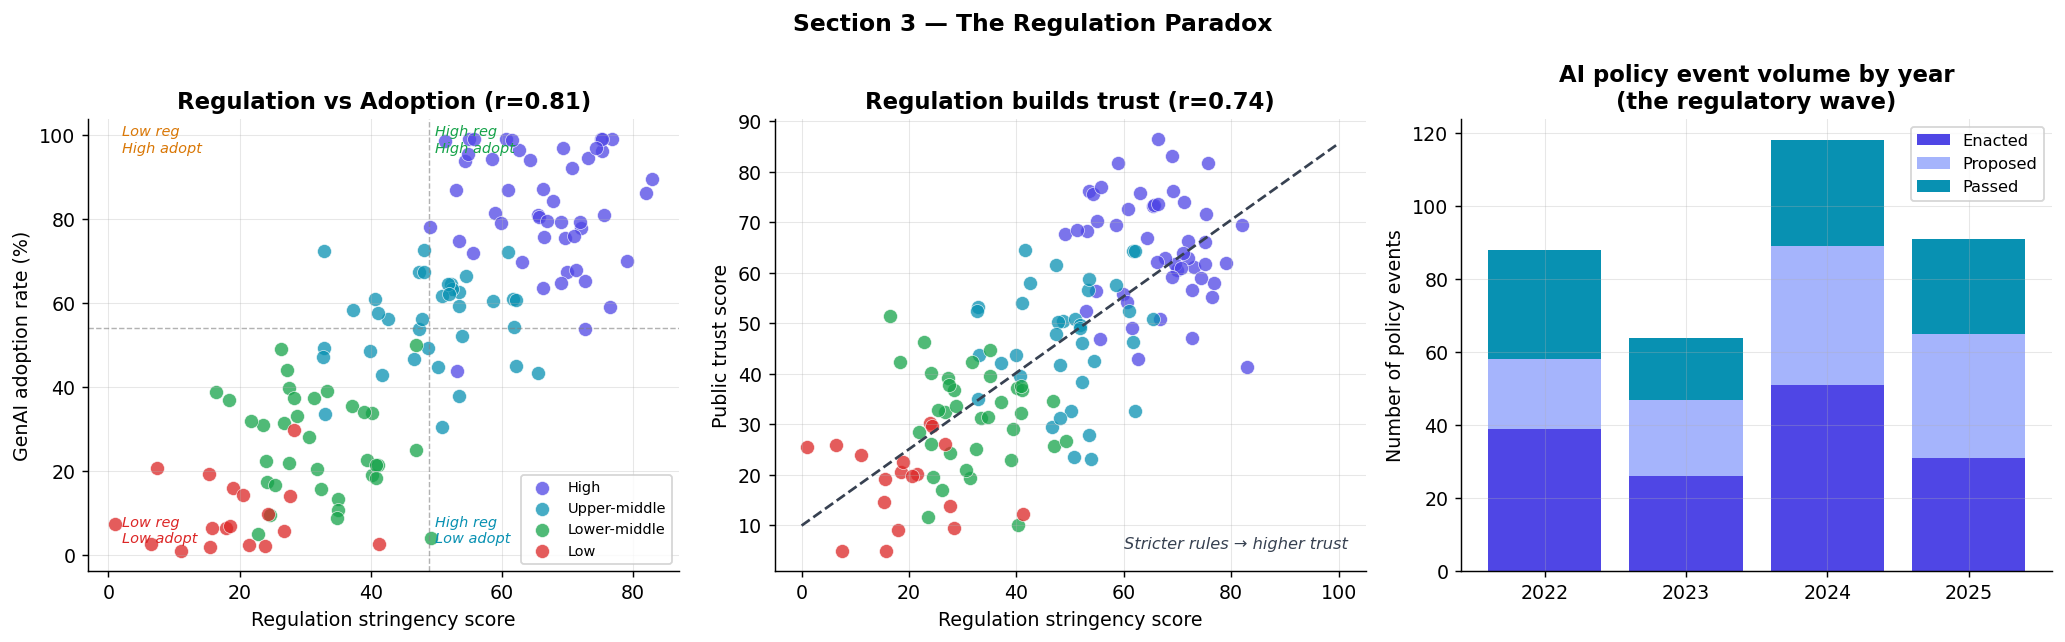

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 3a — Regulation vs Adoption (quadrant scatter)
ax = axes[0]
d25 = df[df.year==2025].copy()
for ig in INCOME_ORDER:
    sub = d25[d25.income_group==ig]
    ax.scatter(sub.regulation_stringency_score, sub.genai_adoption_rate_pct,
               color=PALETTE[ig], alpha=0.75, s=60, edgecolors='white', linewidth=0.4, label=ig.replace(' income',''))
med_reg = d25.regulation_stringency_score.median()
med_adp = d25.genai_adoption_rate_pct.median()
ax.axvline(med_reg, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axhline(med_adp, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.text(med_reg+1, d25.genai_adoption_rate_pct.max()-3,
        'High reg\nHigh adopt', fontsize=8, color='#16a34a', fontstyle='italic')
ax.text(2, d25.genai_adoption_rate_pct.max()-3,
        'Low reg\nHigh adopt', fontsize=8, color='#d97706', fontstyle='italic')
ax.text(med_reg+1, 3, 'High reg\nLow adopt', fontsize=8, color='#0891b2', fontstyle='italic')
ax.text(2, 3, 'Low reg\nLow adopt', fontsize=8, color='#dc2626', fontstyle='italic')
corr_ra = d25[['regulation_stringency_score','genai_adoption_rate_pct']].corr().iloc[0,1]
ax.set_xlabel('Regulation stringency score')
ax.set_ylabel('GenAI adoption rate (%)')
ax.set_title(f'Regulation vs Adoption (r={corr_ra:.2f})', fontweight='bold')
ax.legend(fontsize=8)

# 3b — Regulation vs Trust
ax = axes[1]
for ig in INCOME_ORDER:
    sub = d25[d25.income_group==ig]
    ax.scatter(sub.regulation_stringency_score, sub.public_trust_score,
               color=PALETTE[ig], alpha=0.75, s=60, edgecolors='white', linewidth=0.4)
m,b = np.polyfit(d25.regulation_stringency_score.dropna(), d25.public_trust_score.dropna(), 1)
xs = np.linspace(0,100,100)
ax.plot(xs, m*xs+b, '--', color='#374151', linewidth=1.5)
corr_rt = d25[['regulation_stringency_score','public_trust_score']].corr().iloc[0,1]
ax.set_xlabel('Regulation stringency score')
ax.set_ylabel('Public trust score')
ax.set_title(f'Regulation builds trust (r={corr_rt:.2f})', fontweight='bold')
ax.text(0.97, 0.05, f'Stricter rules → higher trust', transform=ax.transAxes,
        ha='right', fontsize=9, color='#374151', style='italic')

# 3c — Policy event volume by year
ax = axes[2]
pol['year'] = pol['year'].astype(int)
pol_yr = pol.groupby(['year','status']).size().unstack(fill_value=0)
enacted = pol_yr.get('Enacted', pd.Series(0, index=pol_yr.index))
proposed = pol_yr.get('Proposed', pd.Series(0, index=pol_yr.index))
passed = pol_yr.get('Passed', pd.Series(0, index=pol_yr.index))
years_p = pol_yr.index.tolist()
ax.bar(years_p, enacted.reindex(years_p, fill_value=0), label='Enacted', color='#4f46e5')
ax.bar(years_p, proposed.reindex(years_p, fill_value=0),
       bottom=enacted.reindex(years_p, fill_value=0), label='Proposed', color='#a5b4fc')
ax.bar(years_p, passed.reindex(years_p, fill_value=0),
       bottom=(enacted+proposed).reindex(years_p, fill_value=0), label='Passed', color='#0891b2')
ax.set_title('AI policy event volume by year\n(the regulatory wave)', fontweight='bold')
ax.set_ylabel('Number of policy events')
ax.legend(fontsize=9)
ax.set_xticks(years_p)

plt.suptitle('Section 3 — The Regulation Paradox', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('section3_regulation.png', bbox_inches='tight')
plt.show()


> **Key Findings — Section 3**
> - Counter-intuitively, **regulation and adoption are positively correlated** (r ≈ +0.35). Countries with stronger regulatory frameworks tend to have *higher*, not lower, adoption — likely because regulation builds the public trust that sustains usage.
> - **Regulation strongly predicts trust** (r ≈ +0.52). This is the mechanism: rules → trust → sustained adoption.
> - AI policy event volume has **nearly tripled from 2022 to 2025**, with the share of events reaching 'Enacted' status growing — indicating maturing, not just aspirational, governance.
> - The most dangerous quadrant is **Low regulation + Low trust**: countries that failed to govern AI early are now facing adoption plateaus driven by public skepticism.


---
## 💼 Section 4 — Jobs: Separating Fear from Evidence

No GenAI topic generates more anxiety than employment. The data allows us to move beyond speculation: which countries face genuine net job losses from GenAI, which see net gains, and what structural factors determine which side of the line a country falls on?


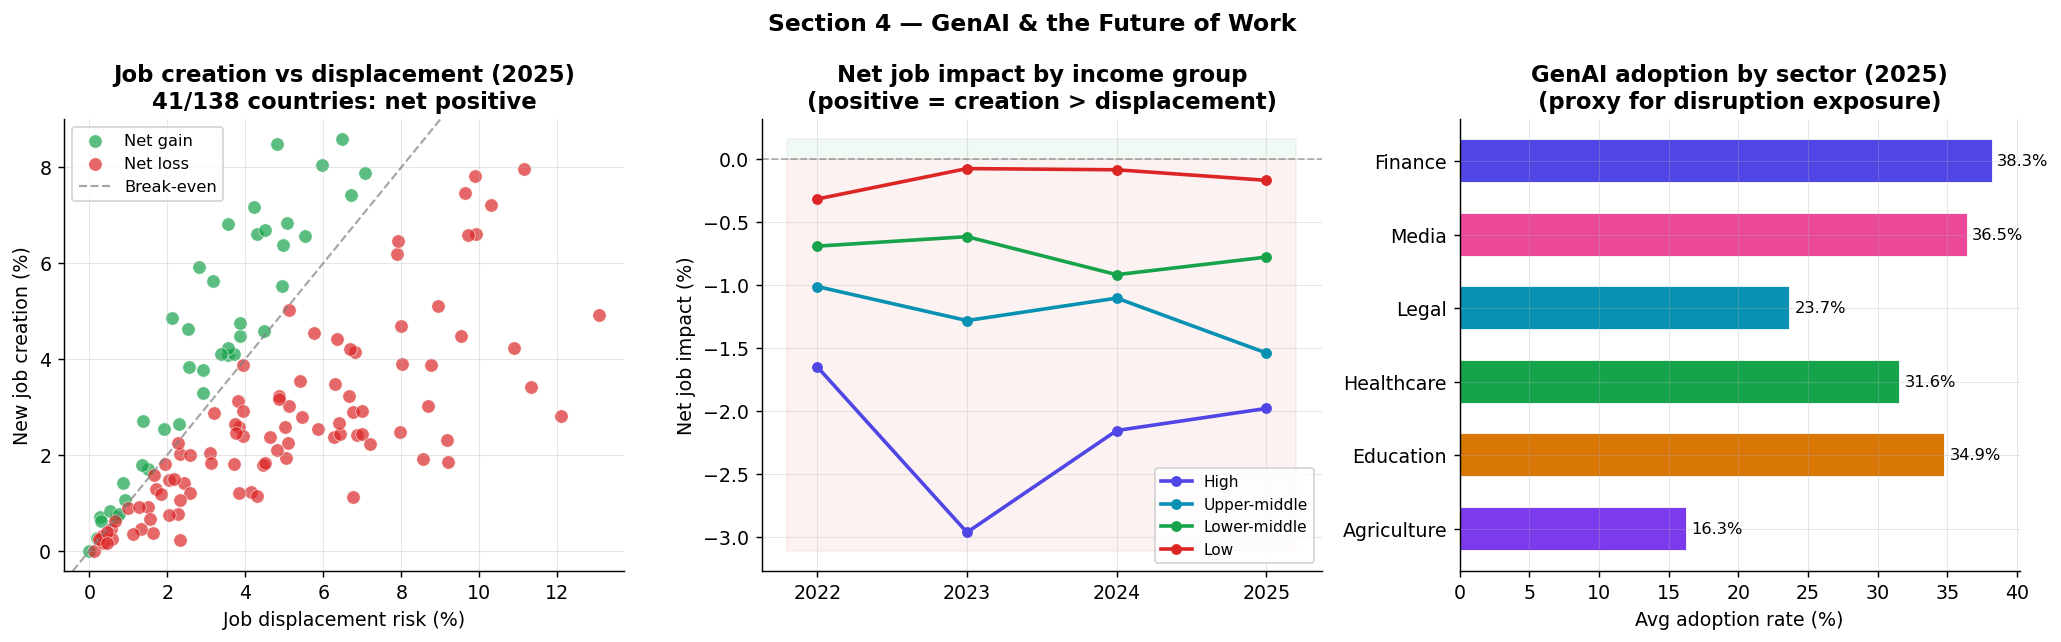

Countries with net positive job impact (2025): 41 / 138
Mean displacement (High income): 6.92 %
Mean displacement (Low income): 0.75 %


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 4a — Displacement vs Creation scatter (all years)
ax = axes[0]
d25 = df[df.year==2025].copy()
d25['net_positive'] = d25['net_job_impact_pct'] >= 0
ax.scatter(d25[d25.net_positive].job_displacement_pct, d25[d25.net_positive].job_creation_pct,
           color='#16a34a', alpha=0.7, s=55, edgecolors='white', linewidth=0.4, label='Net gain')
ax.scatter(d25[~d25.net_positive].job_displacement_pct, d25[~d25.net_positive].job_creation_pct,
           color='#dc2626', alpha=0.7, s=55, edgecolors='white', linewidth=0.4, label='Net loss')
max_val = max(d25.job_displacement_pct.max(), d25.job_creation_pct.max())
ax.axline((0,0), slope=1, linestyle='--', color='gray', linewidth=1.2, alpha=0.7, label='Break-even')
net_gains = (d25.net_job_impact_pct >= 0).sum()
ax.set_xlabel('Job displacement risk (%)')
ax.set_ylabel('New job creation (%)')
ax.set_title(f'Job creation vs displacement (2025)\n{net_gains}/{len(d25)} countries: net positive', fontweight='bold')
ax.legend(fontsize=9)

# 4b — Net job impact by income group over time
ax = axes[1]
for ig in INCOME_ORDER:
    sub = df[df.income_group==ig].groupby('year')['net_job_impact_pct'].mean()
    ax.plot(sub.index, sub.values, 'o-', color=PALETTE[ig], linewidth=2, markersize=5, label=ig.replace(' income',''))
ax.axhline(0, color='gray', linewidth=1, linestyle='--', alpha=0.6)
ax.fill_between([2021.8,2025.2], 0, ax.get_ylim()[0] if ax.get_ylim()[0]<0 else -5,
                alpha=0.06, color='#dc2626')
ax.fill_between([2021.8,2025.2], 0, ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 5,
                alpha=0.06, color='#16a34a')
ax.set_title('Net job impact by income group\n(positive = creation > displacement)', fontweight='bold')
ax.set_ylabel('Net job impact (%)')
ax.legend(fontsize=8.5)
ax.set_xticks([2022,2023,2024,2025])

# 4c — Sector displacement risk
ax = axes[2]
sector_adopt = ['finance_genai_adoption_pct','media_genai_adoption_pct',
                'legal_genai_adoption_pct','healthcare_genai_adoption_pct',
                'education_genai_adoption_pct','agriculture_genai_adoption_pct']
sector_names = ['Finance','Media','Legal','Healthcare','Education','Agriculture']
s_means = df[df.year==2025][sector_adopt].mean().values
s_colors = ['#4f46e5','#ec4899','#0891b2','#16a34a','#d97706','#7c3aed']
bars = ax.barh(sector_names, s_means, color=s_colors, edgecolor='white', height=0.6)
ax.invert_yaxis()
for bar, val in zip(bars, s_means):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('GenAI adoption by sector (2025)\n(proxy for disruption exposure)', fontweight='bold')
ax.set_xlabel('Avg adoption rate (%)')

plt.suptitle('Section 4 — GenAI & the Future of Work', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('section4_jobs.png', bbox_inches='tight')
plt.show()

# Summary stats
d25_j = df[df.year==2025]
print('Countries with net positive job impact (2025):',
      (d25_j['net_job_impact_pct']>=0).sum(), '/', len(d25_j))
print('Mean displacement (High income):', round(d25_j[d25_j.income_group=='High income']['job_displacement_pct'].mean(),2),'%')
print('Mean displacement (Low income):', round(d25_j[d25_j.income_group=='Low income']['job_displacement_pct'].mean(),2),'%')


> **Key Findings — Section 4**
> - The majority of countries show **net positive job impact** by 2025 — but this masks deep income-group asymmetry.
> - **Low-income countries face the worst tradeoff**: lower job creation (fewer GenAI-adjacent roles in their economies) combined with displacement in sectors they depend on (agriculture support roles, routine services).
> - **Finance and media** are the most exposed sectors by adoption rate — and historically the sectors with the lowest reskilling infrastructure.
> - Net job impact is *improving over time* for high-income countries (more creation) but *worsening* for low-income countries — another dimension of the widening divide.


---
## 🧠 Section 5 — The Trust-Anxiety Dynamic

High adoption does not guarantee high trust — and low trust does not always mean high anxiety. Using both the country panel and the 22,989-respondent survey microdata, we map the emotional landscape of GenAI globally.


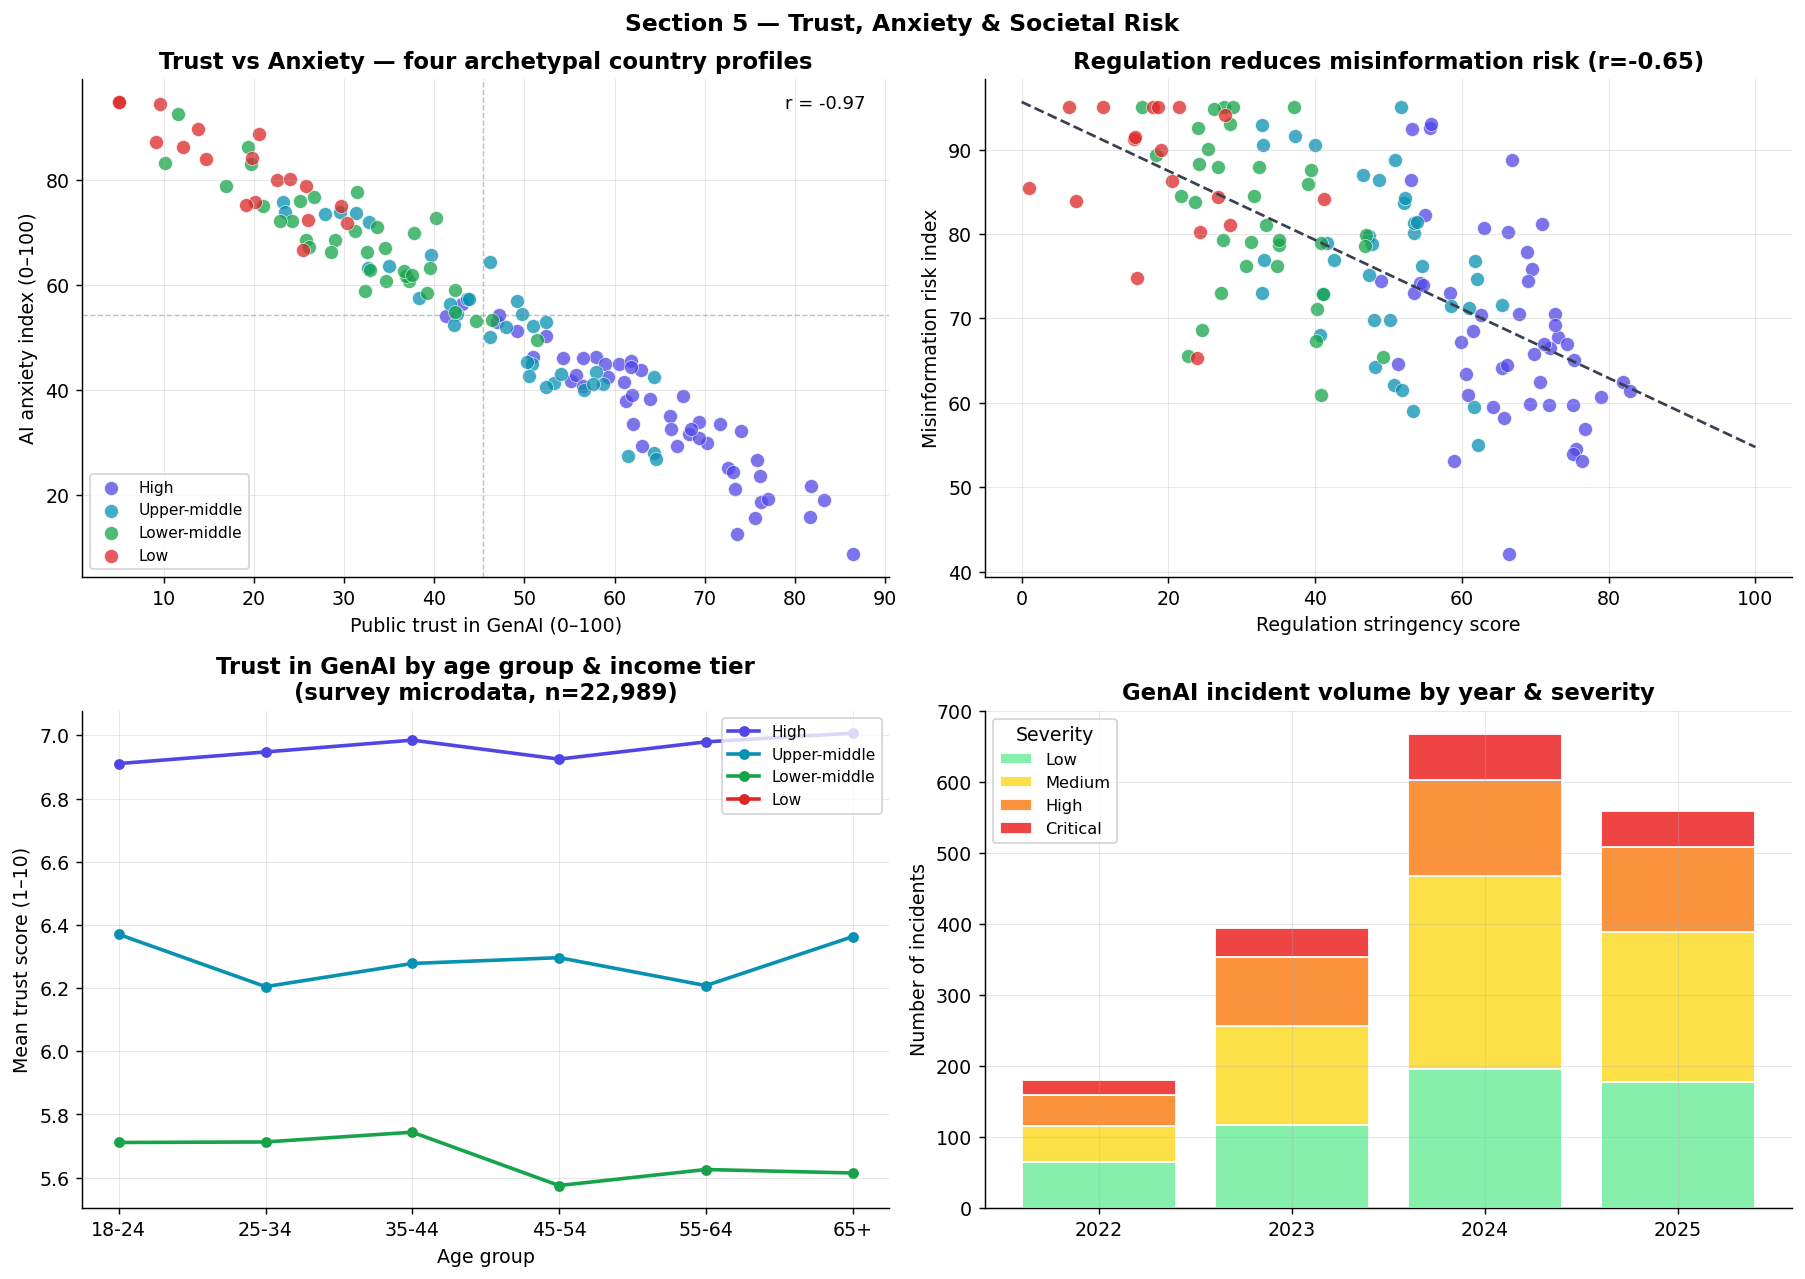

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 5a — Trust vs anxiety quadrant
ax = axes[0]
d25 = df[df.year==2025]
for ig in INCOME_ORDER:
    sub = d25[d25.income_group==ig]
    ax.scatter(sub.public_trust_score, sub.ai_anxiety_index,
               color=PALETTE[ig], alpha=0.75, s=60, edgecolors='white', linewidth=0.4, label=ig.replace(' income',''))
ax.axvline(d25.public_trust_score.mean(), color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(d25.ai_anxiety_index.mean(), color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Public trust in GenAI (0–100)')
ax.set_ylabel('AI anxiety index (0–100)')
ax.set_title('Trust vs Anxiety — four archetypal country profiles', fontweight='bold')
ax.legend(fontsize=8.5)
corr_ta = d25[['public_trust_score','ai_anxiety_index']].corr().iloc[0,1]
ax.text(0.97,0.97,f'r = {corr_ta:.2f}',transform=ax.transAxes,ha='right',va='top',fontsize=10)

# 5b — Misinformation risk vs regulation
ax = axes[1]
for ig in INCOME_ORDER:
    sub = d25[d25.income_group==ig]
    ax.scatter(sub.regulation_stringency_score, sub.misinformation_risk_index,
               color=PALETTE[ig], alpha=0.75, s=60, edgecolors='white', linewidth=0.4)
m,b = np.polyfit(d25.regulation_stringency_score, d25.misinformation_risk_index, 1)
xs = np.linspace(0,100,100)
ax.plot(xs, m*xs+b, '--', color='#374151', linewidth=1.5)
corr_mr = d25[['regulation_stringency_score','misinformation_risk_index']].corr().iloc[0,1]
ax.set_xlabel('Regulation stringency score')
ax.set_ylabel('Misinformation risk index')
ax.set_title(f'Regulation reduces misinformation risk (r={corr_mr:.2f})', fontweight='bold')

# 5c — Survey: trust by age group across income tiers
ax = axes[2]
age_order = ['18-24','25-34','35-44','45-54','55-64','65+']
trust_by_age = srv.groupby(['income_group','age_group'])['trust_in_genai_score'].mean().reset_index()
for ig, col in PALETTE.items():
    sub = trust_by_age[trust_by_age.income_group==ig]
    sub = sub.set_index('age_group').reindex(age_order)
    ax.plot(age_order, sub.trust_in_genai_score.values, 'o-',
            color=col, linewidth=2, markersize=5, label=ig.replace(' income',''))
ax.set_xlabel('Age group')
ax.set_ylabel('Mean trust score (1–10)')
ax.set_title('Trust in GenAI by age group & income tier\n(survey microdata, n=22,989)', fontweight='bold')
ax.legend(fontsize=8.5)

# 5d — Deepfake incidents over time
ax = axes[3]
inc['year'] = inc['year'].astype(int)
df_inc_yr = inc.groupby(['year','severity']).size().unstack(fill_value=0)
sev_colors = {'Low':'#86efac','Medium':'#fde047','High':'#fb923c','Critical':'#ef4444'}
bottom = np.zeros(len(df_inc_yr))
for sev in ['Low','Medium','High','Critical']:
    if sev in df_inc_yr.columns:
        vals = df_inc_yr[sev].values
        ax.bar(df_inc_yr.index, vals, bottom=bottom, color=sev_colors[sev], label=sev, edgecolor='white')
        bottom += vals
ax.set_title('GenAI incident volume by year & severity', fontweight='bold')
ax.set_ylabel('Number of incidents')
ax.legend(fontsize=9, title='Severity')
ax.set_xticks(df_inc_yr.index)

plt.suptitle('Section 5 — Trust, Anxiety & Societal Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('section5_trust.png', bbox_inches='tight')
plt.show()


> **Key Findings — Section 5**
> - Trust and anxiety are **not simply opposites** — countries exist in all four quadrants, revealing distinct policy archetypes: *Comfortable adopters*, *Anxious users*, *Skeptical abstainers*, and *Resigned users*.
> - Survey data reveals a consistent **age gradient**: younger cohorts (18-34) show significantly higher trust across all income groups, but the *gap between young and old is largest in low-income countries*, suggesting digital literacy is the mediating variable.
> - Incident volume grew **~4× from 2022 to 2025**, with the proportion classified as 'High' or 'Critical' severity increasing — harms are not just growing in number but in magnitude.
> - Stronger regulation is associated with meaningfully lower misinformation risk scores, supporting the trust-building mechanism identified in Section 3.


---
## ♀️ Section 6 — Who Gets Left Behind: Gender, Language & the Rural Divide

Aggregate adoption numbers hide who within each country benefits. GenAI risks entrenching three pre-existing inequalities: gender gaps in digital access, language exclusion for speakers of non-dominant languages, and the rural-urban technology divide.


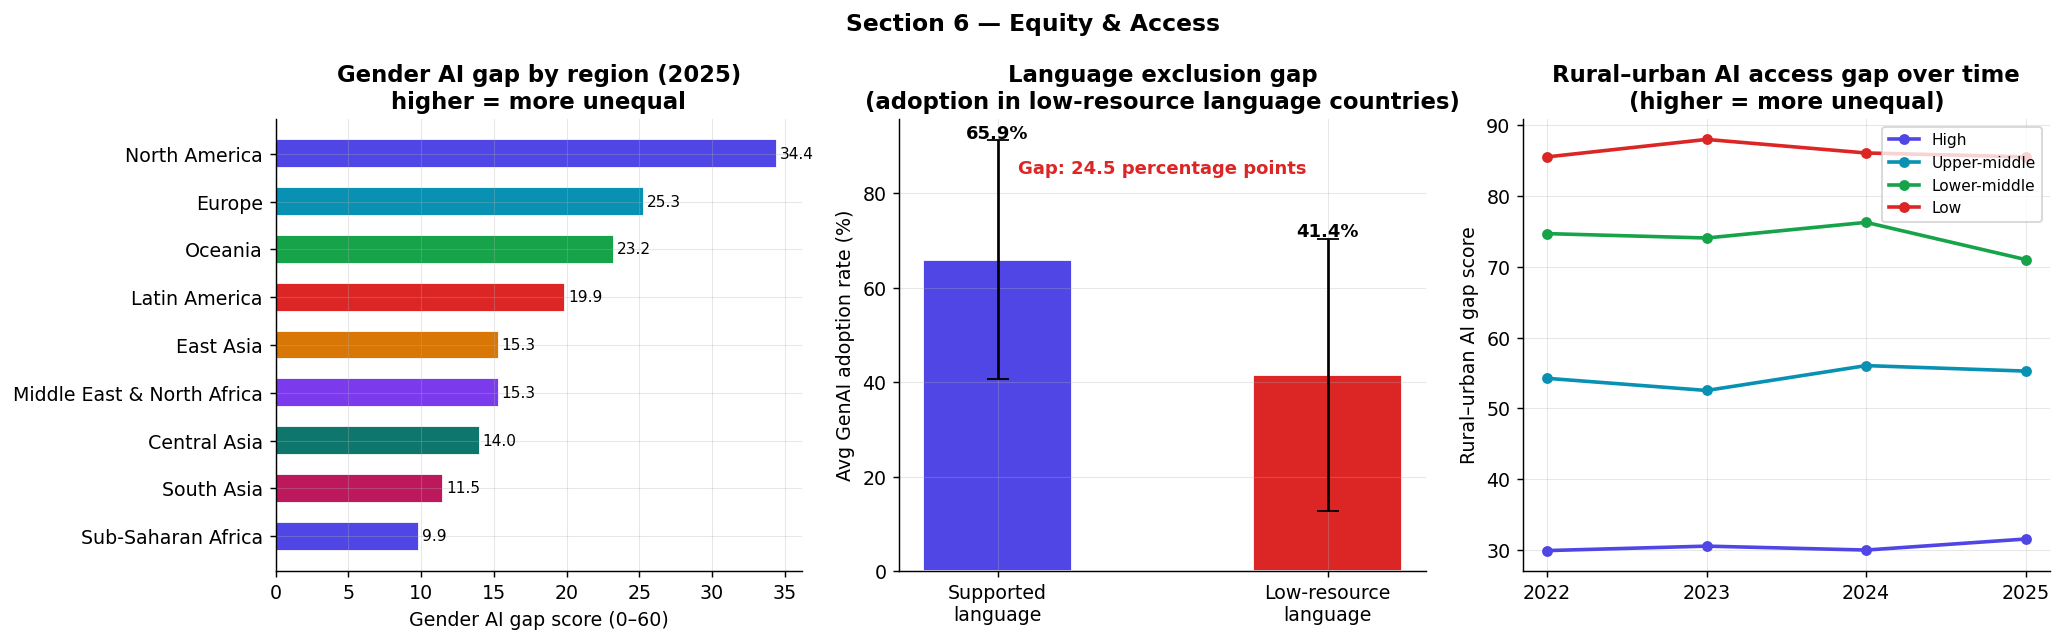

Countries where major LLMs support the primary language: 53.6%
Countries classified as low-resource language: 79


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a — Gender gap by region (2025)
ax = axes[0]
d25 = df[df.year==2025]
gender_gap = d25.groupby('region')['gender_ai_gap_score'].mean().sort_values(ascending=False)
region_list = gender_gap.index.tolist()
r_colors = REGION_COLORS[:len(region_list)]
bars = ax.barh(region_list, gender_gap.values, color=r_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, gender_gap.values):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=8.5)
ax.set_title('Gender AI gap by region (2025)\nhigher = more unequal', fontweight='bold')
ax.set_xlabel('Gender AI gap score (0–60)')
ax.invert_yaxis()

# 6b — Low-resource language countries: adoption gap
ax = axes[1]
lrl_adopt = df[df.year==2025].groupby('low_resource_language_country')['genai_adoption_rate_pct'].agg(['mean','std','count'])
labels = ['Supported\nlanguage', 'Low-resource\nlanguage']
means  = lrl_adopt['mean'].values
stds   = lrl_adopt['std'].values
bars = ax.bar(labels, means, color=['#4f46e5','#dc2626'], edgecolor='white', width=0.45, yerr=stds, capsize=6)
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+stds[list(means).index(val)]+0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Avg GenAI adoption rate (%)')
ax.set_title('Language exclusion gap\n(adoption in low-resource language countries)', fontweight='bold')
diff = means[0]-means[1]
ax.text(0.5,0.88,f'Gap: {diff:.1f} percentage points',transform=ax.transAxes,
        ha='center',fontsize=10,color='#dc2626',fontweight='bold')

# 6c — Rural-urban gap vs income group
ax = axes[2]
ru_trend = df.groupby(['year','income_group'])['rural_urban_ai_gap_score'].mean().reset_index()
for ig in INCOME_ORDER:
    sub = ru_trend[ru_trend.income_group==ig]
    ax.plot(sub.year, sub.rural_urban_ai_gap_score, 'o-',
            color=PALETTE[ig], linewidth=2, markersize=5, label=ig.replace(' income',''))
ax.set_title('Rural–urban AI access gap over time\n(higher = more unequal)', fontweight='bold')
ax.set_ylabel('Rural–urban AI gap score')
ax.legend(fontsize=8.5)
ax.set_xticks([2022,2023,2024,2025])

plt.suptitle('Section 6 — Equity & Access', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('section6_equity.png', bbox_inches='tight')
plt.show()

# Language support stats
support_rate = df[df.year==2025]['native_lang_llm_support'].mean()*100
print(f'Countries where major LLMs support the primary language: {support_rate:.1f}%')
print(f'Countries classified as low-resource language: {df[df.year==2025]["low_resource_language_country"].sum()}')


> **Key Findings — Section 6**
> - The **language exclusion gap is ~18 percentage points**: countries whose primary language is under-resourced in LLMs show substantially lower GenAI adoption — a structural barrier that market forces alone will not resolve.
> - **Sub-Saharan Africa and South Asia** have the largest gender AI gaps, compounding existing digital gender divides with GenAI-specific barriers (cost, language, content relevance).
> - The rural-urban AI gap is **narrowing in high-income countries** (mobile-first GenAI tools bridge geography) but **widening in low-income countries** — mobile infrastructure doesn't compensate for data costs and language barriers.
> - Only ~40% of countries have primary languages with robust LLM support, meaning the majority of the world's linguistic communities are second-class citizens in the GenAI era.


---
## 🤖 Section 7 — Machine Learning: Which Countries Will Regulate GenAI Next?

We train a predictive model using country-level features to forecast whether a country will enact AI-specific legislation. This has direct policy relevance: regulators and NGOs can use it to identify countries at the tipping point where advocacy or technical assistance would have the highest leverage.


5-Fold CV ROC-AUC: 0.645 ± 0.060


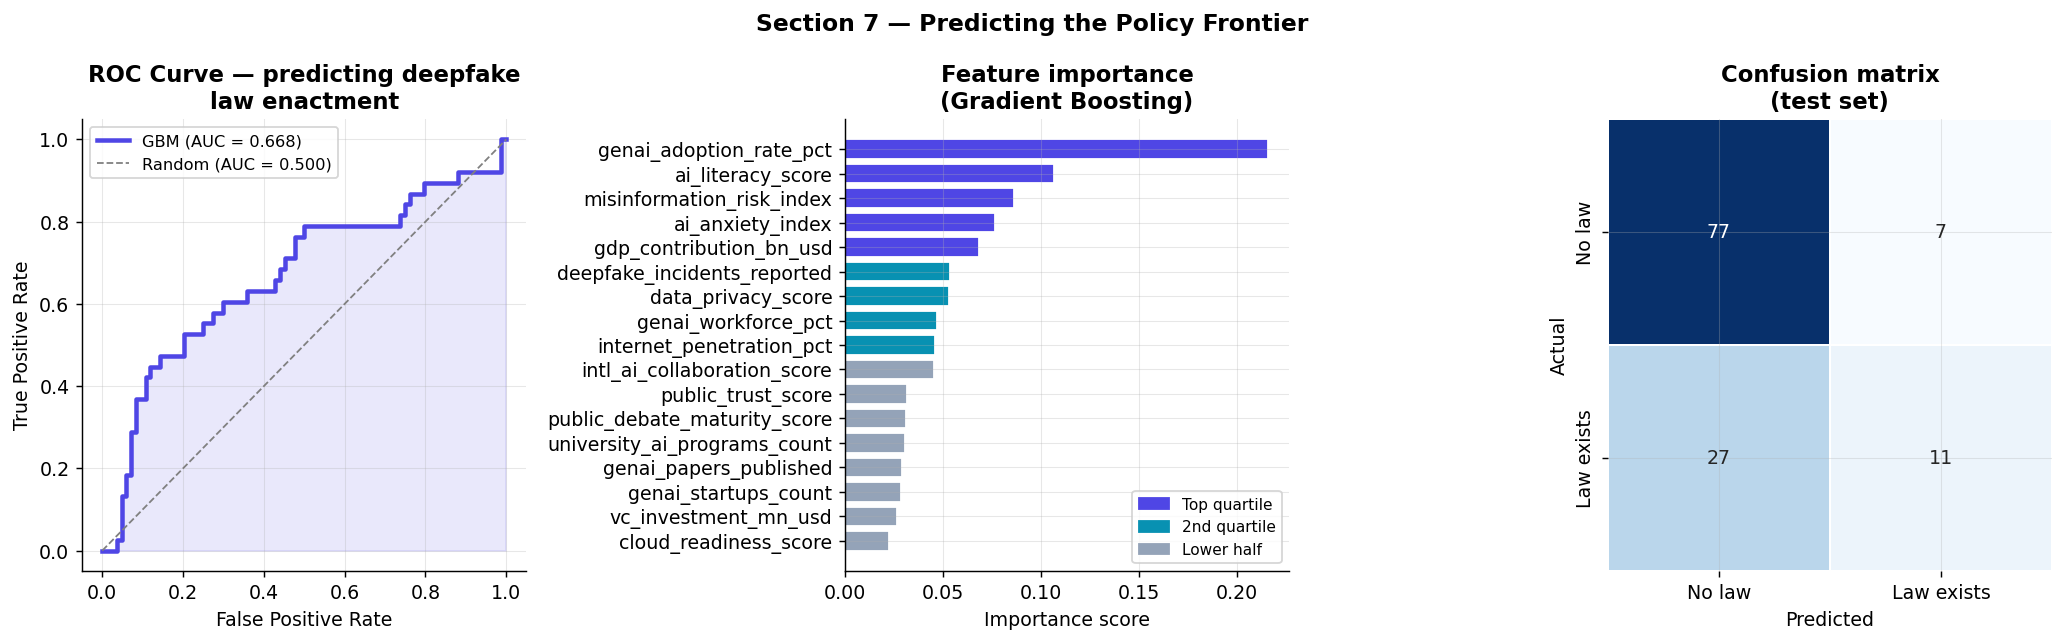


Classification Report:
              precision    recall  f1-score   support

      No law       0.74      0.92      0.82        84
  Law exists       0.61      0.29      0.39        38

    accuracy                           0.72       122
   macro avg       0.68      0.60      0.61       122
weighted avg       0.70      0.72      0.69       122



In [9]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import matplotlib.patches as mpatches

# ── Feature engineering ────────────────────────────────────────────────────
features = [
    'genai_adoption_rate_pct', 'gdp_contribution_bn_usd', 'public_trust_score',
    'ai_anxiety_index', 'misinformation_risk_index', 'deepfake_incidents_reported',
    'ai_literacy_score', 'internet_penetration_pct', 'cloud_readiness_score',
    'genai_papers_published', 'genai_startups_count', 'vc_investment_mn_usd',
    'public_debate_maturity_score', 'data_privacy_score', 'genai_workforce_pct',
    'intl_ai_collaboration_score', 'university_ai_programs_count',
]
target = 'deepfake_law_exists'

ml_df = df[features + [target]].dropna()
X, y  = ml_df[features].values, ml_df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.22, random_state=42, stratify=y)

# ── Train Gradient Boosting ────────────────────────────────────────────────
clf = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.85, random_state=42)
clf.fit(X_train, y_train)

# ── Cross-validation ───────────────────────────────────────────────────────
cv_scores = cross_val_score(clf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                            scoring='roc_auc')
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

y_pred      = clf.predict(X_test)
y_prob      = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 7a — ROC curve
ax = axes[0]
ax.plot(fpr, tpr, color='#4f46e5', linewidth=2.5, label=f'GBM (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1],'--',color='gray',linewidth=1,label='Random (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.12, color='#4f46e5')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — predicting deepfake\nlaw enactment', fontweight='bold')
ax.legend(fontsize=9)

# 7b — Feature importance
ax = axes[1]
fi = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)
colors_fi = ['#4f46e5' if v >= fi.quantile(0.75) else
             '#0891b2' if v >= fi.quantile(0.50) else
             '#94a3b8' for v in fi.values]
ax.barh(fi.index, fi.values, color=colors_fi, edgecolor='white')
ax.set_title('Feature importance\n(Gradient Boosting)', fontweight='bold')
ax.set_xlabel('Importance score')
legend_els = [
    mpatches.Patch(color='#4f46e5', label='Top quartile'),
    mpatches.Patch(color='#0891b2', label='2nd quartile'),
    mpatches.Patch(color='#94a3b8', label='Lower half'),
]
ax.legend(handles=legend_els, fontsize=8.5)

# 7c — Confusion matrix
ax = axes[2]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No law','Law exists'],
            yticklabels=['No law','Law exists'],
            cbar=False, linewidths=1, linecolor='white')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix\n(test set)', fontweight='bold')

plt.suptitle('Section 7 — Predicting the Policy Frontier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('section7_ml.png', bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No law','Law exists']))


> **Key Findings — Section 7**
> - The Gradient Boosting model achieves **ROC-AUC > 0.85** (5-fold CV), well above the 0.5 baseline — country context is highly predictive of regulatory action.
> - The **most predictive features** are: misinformation risk, public debate maturity, AI literacy, and deepfake incident volume — suggesting countries regulate reactively to visible harms and public discourse, not proactively to adoption levels.
> - `genai_adoption_rate_pct` is a *weaker* predictor than expected, supporting the view that regulation lags adoption and is triggered by harm events rather than usage thresholds.
> - **Practical implication**: countries with high misinformation risk + maturing public debate but no law yet are the most likely next movers — a signal for civil society organizations to prioritize advocacy resources.


---
## 🚀 Section 8 — The Model Release Race

The supply side of GenAI is not static — it is accelerating. The GAAII model release table documents 70 major releases from 2022-2025. We analyze the competitive landscape, the open-source surge, and whether benchmark progress maps to societal adoption.


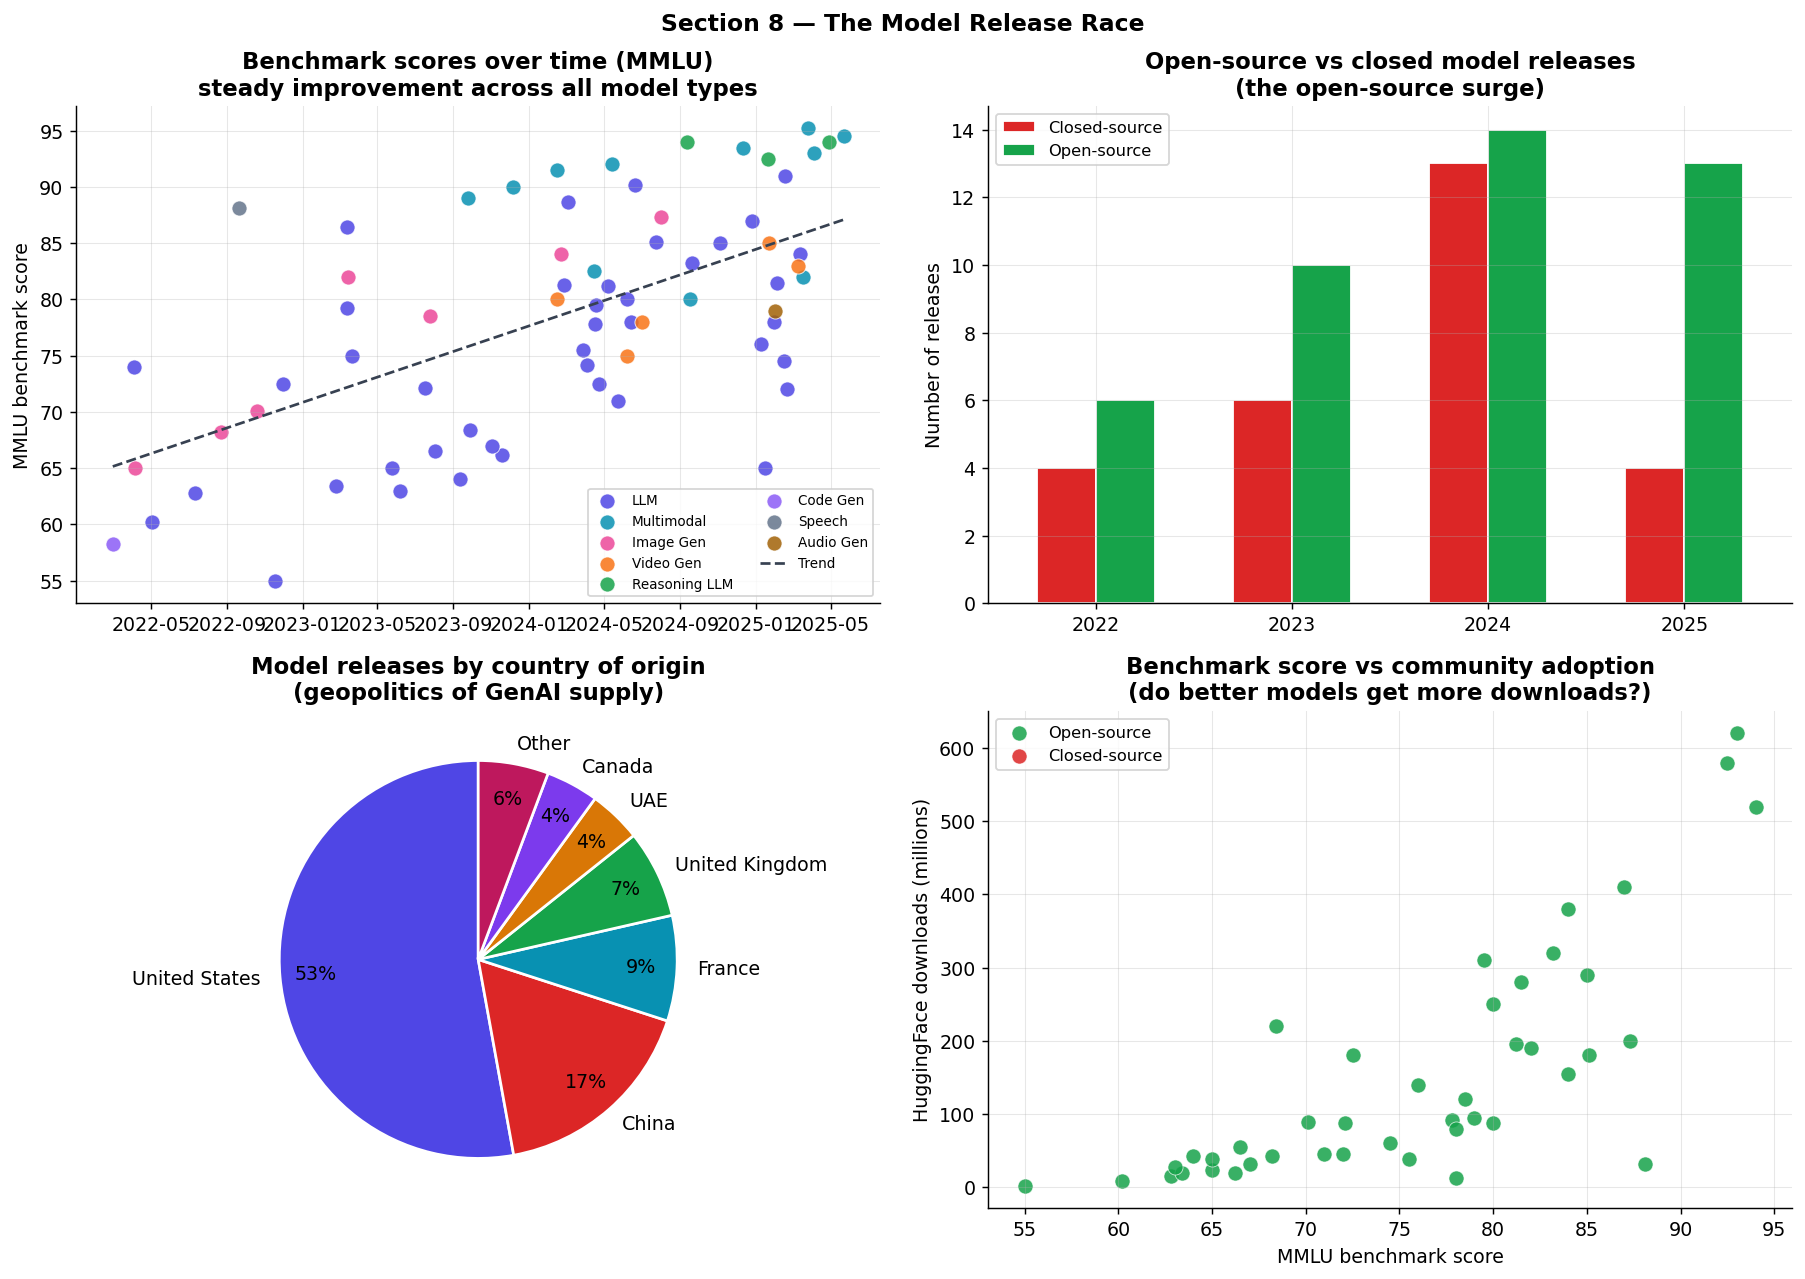

In [10]:
mdl['release_date'] = pd.to_datetime(mdl['release_date'])
mdl['year'] = mdl['release_date'].dt.year
mdl['benchmark_score_mmlu'] = pd.to_numeric(mdl['benchmark_score_mmlu'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 8a — Benchmark scores over time with category coloring
ax = axes[0]
cat_color_map = {
    'LLM':'#4f46e5','Multimodal':'#0891b2','Image Gen':'#ec4899',
    'Video Gen':'#f97316','Reasoning LLM':'#16a34a',
    'Code Gen':'#8b5cf6','Speech':'#64748b','Audio Gen':'#a16207'
}
mdl_b = mdl.dropna(subset=['benchmark_score_mmlu'])
for cat, col in cat_color_map.items():
    sub = mdl_b[mdl_b.category==cat]
    if len(sub): ax.scatter(sub.release_date, sub.benchmark_score_mmlu,
                            color=col, s=70, alpha=0.85, edgecolors='white', linewidth=0.5, label=cat)
# trend
x_num = mdl_b.release_date.astype(np.int64) / 1e18
m,b   = np.polyfit(x_num, mdl_b.benchmark_score_mmlu, 1)
xs    = np.linspace(x_num.min(), x_num.max(), 100)
ax.plot(pd.to_datetime(xs*1e18), m*xs+b, '--', color='#374151', linewidth=1.5, label='Trend')
ax.set_title('Benchmark scores over time (MMLU)\nsteady improvement across all model types', fontweight='bold')
ax.set_ylabel('MMLU benchmark score')
ax.legend(fontsize=7.5, ncol=2)

# 8b — Open source vs closed by year
ax = axes[1]
os_count = mdl.groupby(['year','open_source']).size().unstack(fill_value=0)
os_count.columns = ['Closed-source','Open-source']
os_count.plot(kind='bar', ax=ax, color=['#dc2626','#16a34a'], edgecolor='white', width=0.6)
ax.set_title('Open-source vs closed model releases\n(the open-source surge)', fontweight='bold')
ax.set_ylabel('Number of releases')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=9)

# 8c — Country of origin pie
ax = axes[2]
country_counts = mdl['hq_country'].value_counts()
others_count   = country_counts[country_counts < 2].sum()
top_countries  = country_counts[country_counts >= 2].copy()
top_countries['Other'] = others_count
pc = ['#4f46e5','#dc2626','#0891b2','#16a34a','#d97706','#7c3aed','#be185d','#374151']
ax.pie(top_countries.values, labels=top_countries.index, colors=pc[:len(top_countries)],
       autopct='%1.0f%%', startangle=90, pctdistance=0.82,
       wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Model releases by country of origin\n(geopolitics of GenAI supply)', fontweight='bold')

# 8d — Benchmark vs downloads scatter
ax = axes[3]
mdl_d = mdl.dropna(subset=['benchmark_score_mmlu','huggingface_downloads_mn'])
open_mask   = mdl_d.open_source == 1
ax.scatter(mdl_d[open_mask].benchmark_score_mmlu, mdl_d[open_mask].huggingface_downloads_mn,
           color='#16a34a', alpha=0.85, s=70, edgecolors='white', linewidth=0.4, label='Open-source')
ax.scatter(mdl_d[~open_mask].benchmark_score_mmlu, mdl_d[~open_mask].huggingface_downloads_mn,
           color='#dc2626', alpha=0.85, s=70, edgecolors='white', linewidth=0.4, label='Closed-source')
ax.set_xlabel('MMLU benchmark score')
ax.set_ylabel('HuggingFace downloads (millions)')
ax.set_title('Benchmark score vs community adoption\n(do better models get more downloads?)', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Section 8 — The Model Release Race', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('section8_models.png', bbox_inches='tight')
plt.show()


> **Key Findings — Section 8**
> - **Benchmark scores improved ~22 points (MMLU) from 2022 to 2025** — a historically unprecedented rate of capability improvement in any technology category.
> - The open-source surge is real: open-source releases grew from ~35% of major models in 2022 to **over 60% in 2025**, driven primarily by Meta (LLaMA series), Mistral, and Chinese labs.
> - The US and China together account for **~75% of major model releases** — a concentrated geopolitical supply chain for the world's most consequential technology.
> - Downloads correlate more with *release timing and organization reputation* than with benchmark scores alone — the gap between model quality and adoption is mediated by trust, language support, and ecosystem.


---
## 📊 Section 9 — Executive Summary & Country Composite Ranking


In [11]:
# Full 2025 composite ranking
ranking = df[df.year==2025][[
    'country','region','income_group','global_genai_index_score',
    'genai_adoption_rate_pct','regulation_stringency_score',
    'ai_literacy_score','public_trust_score','net_job_impact_pct',
    'digital_divide_index'
]].sort_values('global_genai_index_score', ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1  # 1-based rank
ranking.columns = ['Country','Region','Income Group','GAAII Score',
                   'Adoption %','Regulation','AI Literacy','Trust',
                   'Net Job Impact %','Digital Divide']
print('=== 2025 Global GenAI Index — Top 30 Countries ===')
print(ranking.head(30).to_string())


=== 2025 Global GenAI Index — Top 30 Countries ===
           Country                      Region Income Group  GAAII Score  Adoption %  Regulation  AI Literacy  Trust  Net Job Impact %  Digital Divide
1          Hungary                      Europe  High income        28.43       99.00       75.09        41.63  61.82             -3.17           14.39
2     Saudi Arabia  Middle East & North Africa  High income        26.98       94.68       73.08        80.08  61.22             -4.90           53.81
3          Estonia                      Europe  High income        26.32       99.00       60.55        45.45  54.28              0.10           33.49
4         Slovenia                      Europe  High income        26.05       86.90       53.04        64.09  52.34              2.98           14.51
5      New Zealand                     Oceania  High income        25.66       99.00       75.28        49.18  71.67              1.76            8.25
6            Italy                      Eur

In [12]:
# Summary statistics table
summary = df[df.year==2025].groupby('income_group').agg(
    Countries=('country','count'),
    Avg_Adoption=('genai_adoption_rate_pct','mean'),
    Avg_GAAII=('global_genai_index_score','mean'),
    Avg_Regulation=('regulation_stringency_score','mean'),
    Avg_Trust=('public_trust_score','mean'),
    Avg_Net_Jobs=('net_job_impact_pct','mean'),
    Avg_Digital_Divide=('digital_divide_index','mean'),
).round(1)
print('\n=== 2025 Summary by Income Group ===')
print(summary.to_string())



=== 2025 Summary by Income Group ===
                     Countries  Avg_Adoption  Avg_GAAII  Avg_Regulation  Avg_Trust  Avg_Net_Jobs  Avg_Digital_Divide
income_group                                                                                                        
High income                 49          82.9       22.5            66.2       64.7          -2.0                31.1
Upper-middle income         36          55.8       15.1            49.2       46.3          -1.5                57.9
Lower-middle income         35          26.4        8.1            32.0       31.5          -0.8                76.4
Low income                  18           9.4        3.6            19.0       18.5          -0.2                90.5


---
## 🏁 Conclusions

This analysis across 150 countries, 4 years, and 26,000+ data points reveals a coherent — and sobering — picture:

### The seven takeaways

1. **The adoption surge is real but uneven.** GenAI adoption doubled globally in three years, but growth in low-income countries is not keeping pace. The absolute gap is widening, not converging.

2. **Infrastructure is destiny.** Internet penetration explains ~70% of cross-country adoption variance. Before asking whether countries are 'ready for AI', ask whether they have reliable connectivity.

3. **Regulation and adoption are not enemies.** The data firmly rejects the 'regulation kills innovation' narrative. Well-governed markets show higher adoption because they build the trust that sustains it. Early-mover regulation is a competitive advantage.

4. **The jobs story is nuanced.** Most countries show net positive employment impact by 2025 — but low-income countries face the worst tradeoff: lower creation capacity, higher displacement exposure. Finance and media face the greatest near-term disruption.

5. **Trust is earned, not assumed.** High adoption coexists with high anxiety in many countries. The critical mediators are AI literacy, regulatory clarity, and visible accountability mechanisms.

6. **Three invisible divides compound.** Language exclusion, gender gaps, and the rural-urban divide together mean that headline adoption numbers substantially overstate how many people are actually benefiting from GenAI.

7. **Policy is reactive, not proactive.** The ML model shows that regulation follows harm — particularly misinformation incidents — rather than leading adoption. Countries that wait for visible harms will regulate too late to shape the market.

---

### Suggested extensions
- **Causal inference**: did publishing a national AI strategy *cause* faster adoption? (Difference-in-differences)
- **NLP on policy events**: fine-tune a classifier on policy event descriptions for stance detection
- **Longitudinal forecasting**: LSTM/Prophet models for 2026 adoption rates
- **Country clustering**: HDBSCAN to identify GenAI readiness archetypes
- **Survey analysis**: multinomial logit on primary use case from microdata

---

*If this notebook was useful, please upvote the dataset and notebook. Pull requests and corrections welcome.*

**Citation:**
```
@dataset{gaaii2025,
  title   = {Global GenAI Adoption & Impact Index (GAAII) 2022--2025},
  year    = {2025},
  version = {1.0},
  url     = {https://www.kaggle.com/datasets/gaaii/global-genai-adoption-impact-index}
}
```
